In [1]:
import numpy as np

def rigid_transform_3D(A, B):
    """
    使用 SVD (Kabsch算法) 计算从 A 到 B 的刚体变换 (R, t)
    使得 B ~= R @ A.T + t
    输入: A, B 形状为 (N, 3)
    返回: R (3, 3), t (3, 1)
    """
    assert A.shape == B.shape

    # 1. 计算质心
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)

    # 2. 去质心
    AA = A - centroid_A
    BB = B - centroid_B

    # 3. 计算协方差矩阵
    H = np.dot(AA.T, BB)

    # 4. SVD 分解
    U, S, Vt = np.linalg.svd(H)

    # 5. 计算旋转矩阵 R
    R = np.dot(Vt.T, U.T)

    # 6. 处理反射情况 (如果行列式为负)
    if np.linalg.det(R) < 0:
        Vt[2, :] *= -1
        R = np.dot(Vt.T, U.T)

    # 7. 计算平移向量 t
    t = centroid_B.T - np.dot(R, centroid_A.T)

    return R, t.reshape(3, 1)

def ransac_rigid_transform(src_points, dst_points, threshold=0.01, iterations=1000):
    """
    带 RANSAC 的刚体变换求解，用于剔除严重漂移的异常值
    threshold: 判断为内点的最大距离误差 (单位：米，根据你的描述设为0.005-0.01比较合适)
    """
    best_inliers = []
    best_R = np.eye(3)
    best_t = np.zeros((3, 1))
    
    n_points = src_points.shape[0]
    
    # 至少需要3个点确定3D变换
    if n_points < 3:
        return rigid_transform_3D(src_points, dst_points)

    for i in range(iterations):
        # 1. 随机选取 4 个点 (3个确定平面，4个更稳健)
        idx = np.random.choice(n_points, 4, replace=False)
        src_sample = src_points[idx]
        dst_sample = dst_points[idx]

        # 2. 计算变换
        R, t = rigid_transform_3D(src_sample, dst_sample)

        # 3. 应用变换到所有源点
        # 变换公式: P_new = (R @ P_old.T + t).T
        src_transformed = (np.dot(R, src_points.T) + t).T

        # 4. 计算误差
        errors = np.linalg.norm(dst_points - src_transformed, axis=1)

        # 5. 统计内点
        current_inliers = np.where(errors < threshold)[0]

        # 6. 更新最佳模型
        if len(current_inliers) > len(best_inliers):
            best_inliers = current_inliers
            best_R = R
            best_t = t
            
    print(f"RANSAC 结束: 共有 {n_points} 个点，其中 {len(best_inliers)} 个被认定为可靠点(Inliers)。")
    
    # 7. Refinement: 使用所有最好的内点重新计算一次 SVD，得到最高精度
    if len(best_inliers) > 3:
        final_R, final_t = rigid_transform_3D(src_points[best_inliers], dst_points[best_inliers])
        return final_R, final_t, best_inliers
    else:
        print("警告: 内点过少，使用原始最佳估计")
        return best_R, best_t, best_inliers

# ================= 这里是主程序 =================

# 1. 准备原始数据 (Reference)
loc_path = "data/sensor_location_129_quarter.txt"
# 假设文件不存在时模拟数据，实际运行时请注释掉模拟部分
try:
    loc_all = np.loadtxt(loc_path)
except:
    print(f"文件 {loc_path} 未找到，请确保路径正确。")
    # 为了演示代码逻辑，这里如果文件不存在会报错停止，请替换为你真实的数据加载
    exit()

sel_step = 2
sel_idx = np.arange(0, loc_all.shape[0], sel_step)
loc_ref = loc_all[sel_idx]  # 这是形状完美的原始阵列 (65, 3)

# 2. 加载粗定位数据 (Noisy Observation)
pred_path = "predicted_array_location.txt"
try:
    loc_pred = np.loadtxt(pred_path) # 这是包含漂移的观测值 (65, 3)
except:
    print(f"文件 {pred_path} 未找到。")
    exit()

# 确保形状一致
assert loc_ref.shape == loc_pred.shape, "原始探头数量与预测探头数量不一致！"

# 3. 设置阈值并运行 RANSAC
# 你提到大部分误差在 0.0015m 左右，严重漂移的很大。
# 阈值设为 0.005m (5mm) 可以安全地包含正常点并剔除严重漂移点。
R_opt, t_opt, inliers = ransac_rigid_transform(loc_ref, loc_pred, threshold=0.005, iterations=2000)

# 4. 生成矫正后的坐标
# 使用计算出的最佳刚体变换，应用到原始的完美阵列上
# 这样不仅修正了位置，还保证了探头之间的相对位置（阵列几何形状）绝对不变
loc_corrected = (np.dot(R_opt, loc_ref.T) + t_opt).T

# 5. 计算并打印误差统计，验证效果
diff_noisy = np.linalg.norm(loc_pred - loc_ref, axis=1) # 这里的直接比较没有意义，因为还没对齐，只是占位
diff_corrected = np.linalg.norm(loc_pred - loc_corrected, axis=1)

print("\n--- 矫正结果统计 ---")
print(f"检测到的异常点(漂移点)数量: {len(loc_ref) - len(inliers)}")
print(f"内点的平均拟合误差: {np.mean(diff_corrected[inliers]):.6f} m")
print(f"异常点的偏差大小(示例): {diff_corrected[np.setdiff1d(np.arange(len(loc_ref)), inliers)]}")

# 6. 保存结果
output_path = "predicted_array_location_corrected.txt"
np.savetxt(output_path, loc_corrected, fmt='%.6f')
print(f"\n矫正后的坐标已保存至: {output_path}")

RANSAC 结束: 共有 65 个点，其中 60 个被认定为可靠点(Inliers)。

--- 矫正结果统计 ---
检测到的异常点(漂移点)数量: 5
内点的平均拟合误差: 0.001147 m
异常点的偏差大小(示例): [0.00872234 0.11849068 0.0721647  0.07095441 0.07138758]

矫正后的坐标已保存至: predicted_array_location_corrected.txt


正在生成可视化图表...


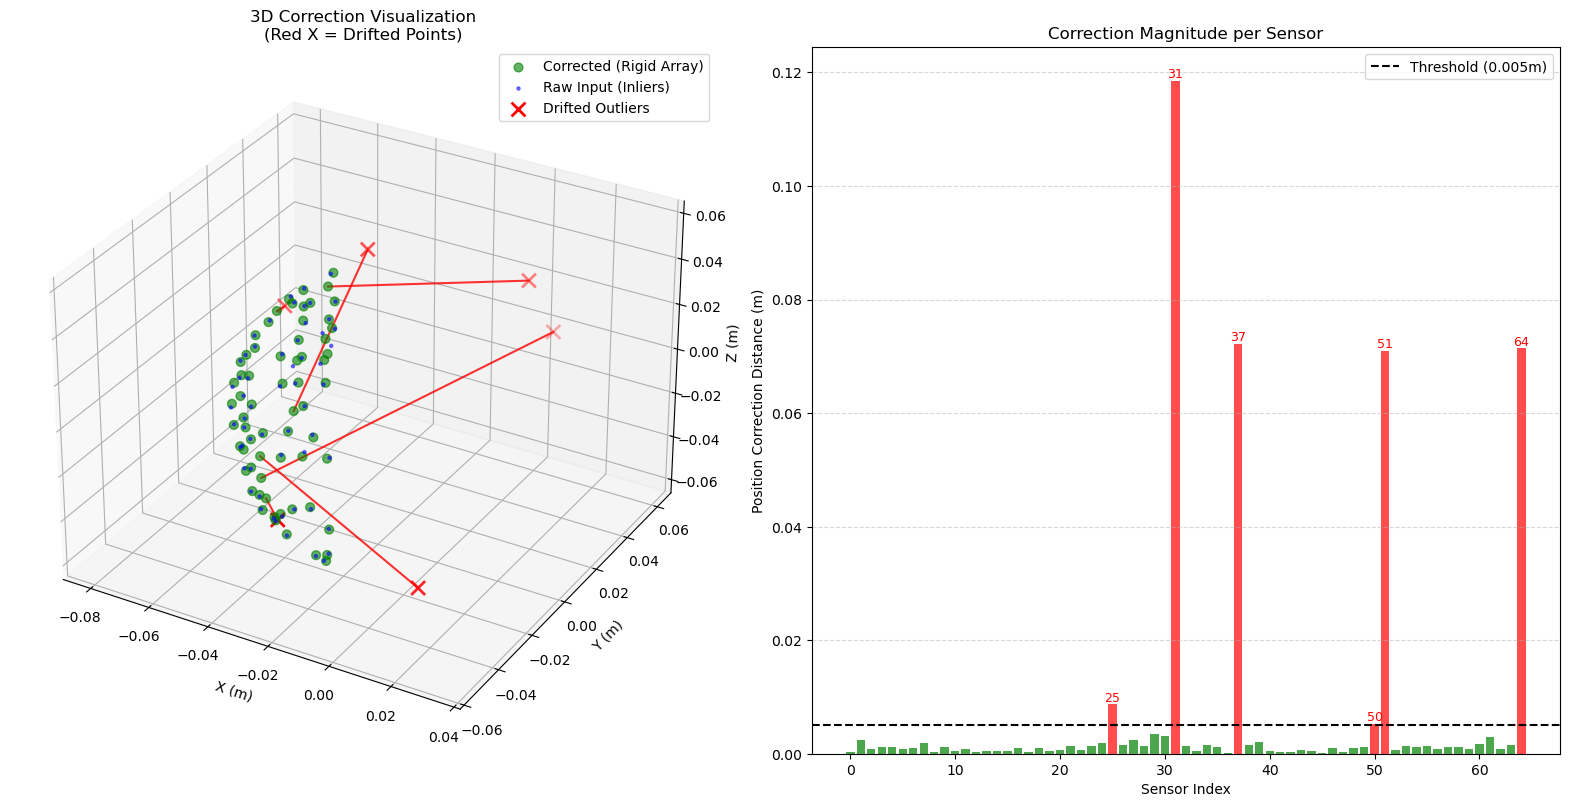

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 辅助函数：设置3D绘图的长宽比一致
# (Matplotlib 默认会自动拉伸坐标轴，容易导致刚体变形看起来像扁的)
# ==========================================
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # 找出最大的范围作为统一的包围盒半径
    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

# ==========================================
# 主可视化函数
# ==========================================
def visualize_results(loc_pred, loc_corrected, threshold=0.005):
    """
    loc_pred: 原始粗定位 (含漂移)
    loc_corrected: 矫正后的位姿
    threshold: 判定为漂移点的阈值 (用于绘图颜色区分)
    """
    
    # 计算每个点的偏差距离
    errors = np.linalg.norm(loc_pred - loc_corrected, axis=1)
    
    # 区分正常点和漂移点 (用于绘图)
    outlier_indices = np.where(errors > threshold)[0]
    
    # 创建画布
    fig = plt.figure(figsize=(16, 8))
    
    # ---------------------------
    # 图1: 3D 空间对比图
    # ---------------------------
    ax1 = fig.add_subplot(121, projection='3d')
    
    # 1. 画出矫正后的标准位置 (绿色圆点)
    # 这是我们要的真值/参考基准
    ax1.scatter(loc_corrected[:, 0], loc_corrected[:, 1], loc_corrected[:, 2], 
                c='green', s=40, alpha=0.6, label='Corrected (Rigid Array)')
    
    # 2. 画出原始预测位置 (红色/蓝色)
    # 正常误差的点用蓝色小点，严重漂移的点用红色大叉
    normal_mask = errors <= threshold
    outlier_mask = errors > threshold
    
    ax1.scatter(loc_pred[normal_mask, 0], loc_pred[normal_mask, 1], loc_pred[normal_mask, 2], 
                c='blue', s=20, marker='.', alpha=0.5, label='Raw Input (Inliers)')
    
    if np.any(outlier_mask):
        ax1.scatter(loc_pred[outlier_mask, 0], loc_pred[outlier_mask, 1], loc_pred[outlier_mask, 2], 
                    c='red', s=100, marker='x', linewidth=2, label='Drifted Outliers')
    
    # 3. 画连接线 (显示矫正幅度)
    # 对于每个点，画一条线连接“预测位置”和“矫正位置”
    for i in range(len(loc_pred)):
        color = 'red' if errors[i] > threshold else 'gray'
        alpha = 0.8 if errors[i] > threshold else 0.2
        linewidth = 1.5 if errors[i] > threshold else 0.5
        
        ax1.plot([loc_pred[i, 0], loc_corrected[i, 0]],
                 [loc_pred[i, 1], loc_corrected[i, 1]],
                 [loc_pred[i, 2], loc_corrected[i, 2]],
                 c=color, alpha=alpha, linewidth=linewidth)

    ax1.set_title("3D Correction Visualization\n(Red X = Drifted Points)")
    ax1.set_xlabel("X (m)")
    ax1.set_ylabel("Y (m)")
    ax1.set_zlabel("Z (m)")
    ax1.legend()
    set_axes_equal(ax1) # 强制坐标轴比例一致
    
    # ---------------------------
    # 图2: 偏差统计柱状图
    # ---------------------------
    ax2 = fig.add_subplot(122)
    
    # 颜色映射：超过阈值为红色，否则为绿色
    bar_colors = ['red' if e > threshold else 'green' for e in errors]
    
    indices = np.arange(len(errors))
    ax2.bar(indices, errors, color=bar_colors, alpha=0.7)
    
    # 画一条阈值线
    ax2.axhline(y=threshold, color='k', linestyle='--', label=f'Threshold ({threshold}m)')
    
    ax2.set_title("Correction Magnitude per Sensor")
    ax2.set_xlabel("Sensor Index")
    ax2.set_ylabel("Position Correction Distance (m)")
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.legend()
    
    # 在漂移严重的点上方标注ID
    for i in outlier_indices:
        ax2.text(i, errors[i], f"{i}", ha='center', va='bottom', fontsize=9, color='red')

    plt.tight_layout()
    plt.show()

# ==========================================
# 运行可视化
# ==========================================
# 假设你已经有了 loc_pred (粗定位数据) 和 loc_corrected (上一段代码算出的结果)
# 如果上一段代码已经运行完毕，直接调用下面的函数即可：

# 阈值建议设为你认为“异常”的界限，比如 0.005m (5mm)
if 'loc_pred' in globals() and 'loc_corrected' in globals():
    print("正在生成可视化图表...")
    visualize_results(loc_pred, loc_corrected, threshold=0.005)
else:
    print("请先运行上一段矫正代码以生成 loc_pred 和 loc_corrected 变量。")

=== 误差统计 ===
平均误差 (Mean Error): 0.000523
最大误差 (Max Error) : 0.000828
最小误差 (Min Error) : 0.000115


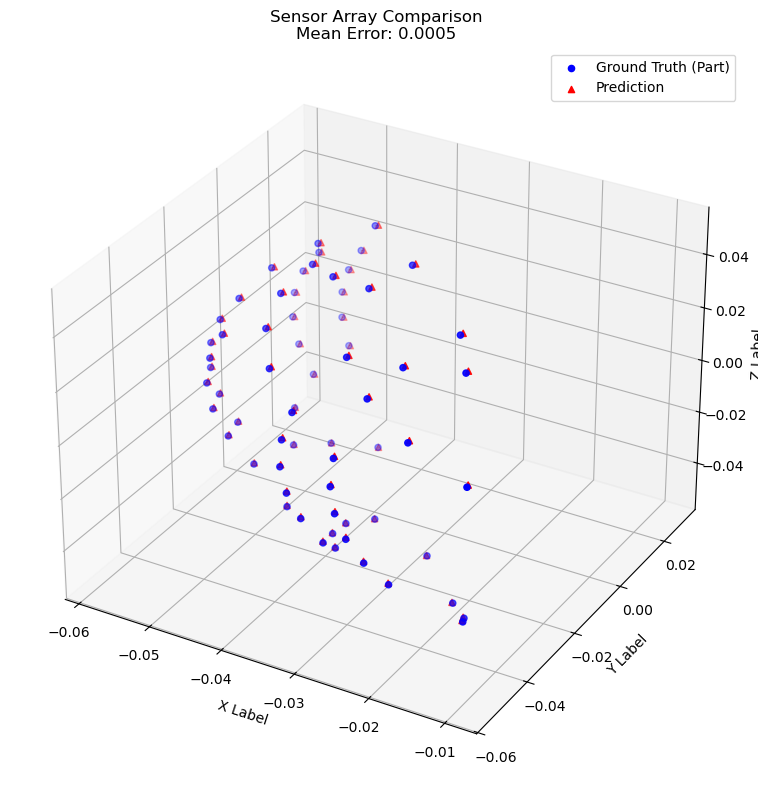

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 必须导入以支持3D绘图


sensor_loc_new_pos = np.loadtxt('data/sensor_location_rotated_120deg.txt')
# （可选）下采样探头以降低计算量
sel_step = 2  # 每隔 sel_step 取一个探头，1 表示全取
sel_idx = np.arange(0, loc_all.shape[0], sel_step)
sensor_loc_new_pos_part = sensor_loc_new_pos[sel_idx]  # (N_sensors, 3)

sensor_loc_new_pos_predict = np.loadtxt('predicted_array_location_corrected.txt')

# ----------------------
# 1. 计算误差 (Calculate Error)
# ----------------------

# 计算对应点之间的欧几里得距离 (L2 norm)
# axis=1 表示沿着坐标维度 (x,y,z) 计算范数
errors = np.linalg.norm(sensor_loc_new_pos_part - sensor_loc_new_pos_predict, axis=1)

# 计算平均误差
mean_error = np.mean(errors)
max_error = np.max(errors)
min_error = np.min(errors)

print(f"=== 误差统计 ===")
print(f"平均误差 (Mean Error): {mean_error:.6f}")
print(f"最大误差 (Max Error) : {max_error:.6f}")
print(f"最小误差 (Min Error) : {min_error:.6f}")

# ----------------------
# 2. 可视化 (Visualization)
# ----------------------

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制真实值 (Ground Truth / Part) - 蓝色圆点
ax.scatter(sensor_loc_new_pos_part[:, 0], 
           sensor_loc_new_pos_part[:, 1], 
           sensor_loc_new_pos_part[:, 2], 
           c='blue', marker='o', s=20, label='Ground Truth (Part)')

# 绘制预测值 (Prediction) - 红色三角
ax.scatter(sensor_loc_new_pos_predict[:, 0], 
           sensor_loc_new_pos_predict[:, 1], 
           sensor_loc_new_pos_predict[:, 2], 
           c='red', marker='^', s=20, label='Prediction')

# (可选) 绘制连接线：将对应的真实点和预测点连起来，直观展示偏差方向
# 如果点很多，可以注释掉这部分代码以保持图面整洁
for i in range(len(sensor_loc_new_pos_part)):
    ax.plot([sensor_loc_new_pos_part[i, 0], sensor_loc_new_pos_predict[i, 0]],
            [sensor_loc_new_pos_part[i, 1], sensor_loc_new_pos_predict[i, 1]],
            [sensor_loc_new_pos_part[i, 2], sensor_loc_new_pos_predict[i, 2]],
            color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# 设置标签和标题
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.set_title(f'Sensor Array Comparison\nMean Error: {mean_error:.4f}')

# 设置图例
ax.legend()

# 调整视角 (可选)
# ax.view_init(elev=20, azim=45) 

plt.tight_layout()
plt.show()

=== 误差统计 ===
平均误差 (Mean Error): 0.000340
最大误差 (Max Error) : 0.000459
最小误差 (Min Error) : 0.000021


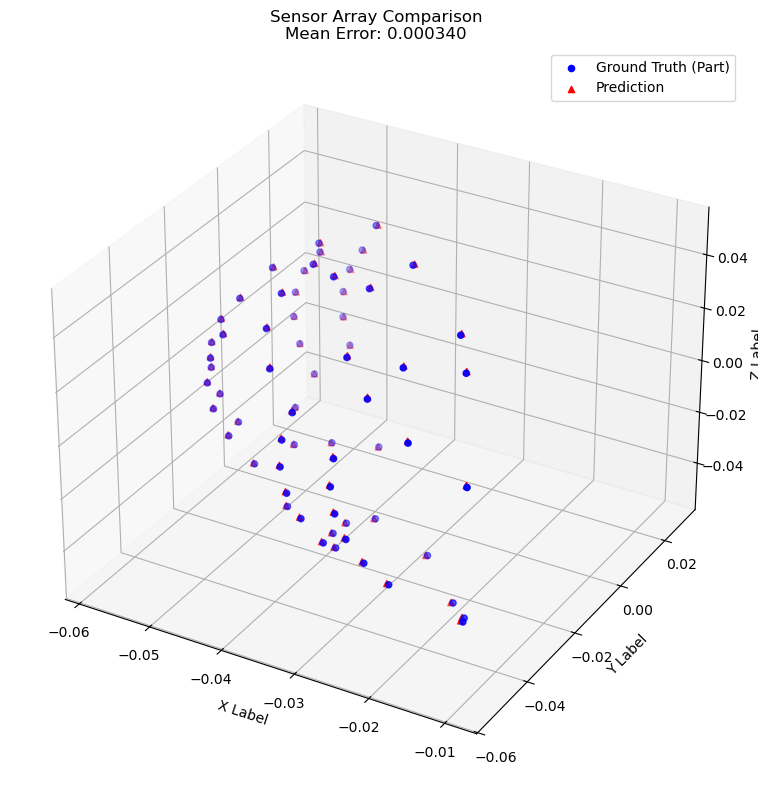

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 必须导入以支持3D绘图


sensor_loc_new_pos = np.loadtxt('data/sensor_location_rotated_120deg.txt')
# （可选）下采样探头以降低计算量
sel_step = 2  # 每隔 sel_step 取一个探头，1 表示全取
sel_idx = np.arange(0, loc_all.shape[0], sel_step)
sensor_loc_new_pos_part = sensor_loc_new_pos[sel_idx]  # (N_sensors, 3)

sensor_loc_new_pos_predict = np.loadtxt('predicted_array_location_finetuned_masked.txt')

# ----------------------
# 1. 计算误差 (Calculate Error)
# ----------------------

# 计算对应点之间的欧几里得距离 (L2 norm)
# axis=1 表示沿着坐标维度 (x,y,z) 计算范数
errors = np.linalg.norm(sensor_loc_new_pos_part - sensor_loc_new_pos_predict, axis=1)

# 计算平均误差
mean_error = np.mean(errors)
max_error = np.max(errors)
min_error = np.min(errors)

print(f"=== 误差统计 ===")
print(f"平均误差 (Mean Error): {mean_error:.6f}")
print(f"最大误差 (Max Error) : {max_error:.6f}")
print(f"最小误差 (Min Error) : {min_error:.6f}")

# ----------------------
# 2. 可视化 (Visualization)
# ----------------------

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制真实值 (Ground Truth / Part) - 蓝色圆点
ax.scatter(sensor_loc_new_pos_part[:, 0], 
           sensor_loc_new_pos_part[:, 1], 
           sensor_loc_new_pos_part[:, 2], 
           c='blue', marker='o', s=20, label='Ground Truth (Part)')

# 绘制预测值 (Prediction) - 红色三角
ax.scatter(sensor_loc_new_pos_predict[:, 0], 
           sensor_loc_new_pos_predict[:, 1], 
           sensor_loc_new_pos_predict[:, 2], 
           c='red', marker='^', s=20, label='Prediction')

# (可选) 绘制连接线：将对应的真实点和预测点连起来，直观展示偏差方向
# 如果点很多，可以注释掉这部分代码以保持图面整洁
for i in range(len(sensor_loc_new_pos_part)):
    ax.plot([sensor_loc_new_pos_part[i, 0], sensor_loc_new_pos_predict[i, 0]],
            [sensor_loc_new_pos_part[i, 1], sensor_loc_new_pos_predict[i, 1]],
            [sensor_loc_new_pos_part[i, 2], sensor_loc_new_pos_predict[i, 2]],
            color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# 设置标签和标题
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.set_title(f'Sensor Array Comparison\nMean Error: {mean_error:.6f}')

# 设置图例
ax.legend()

# 调整视角 (可选)
# ax.view_init(elev=20, azim=45) 

plt.tight_layout()
plt.show()

=== 误差统计 ===
平均误差 (Mean): 0.000340
最大误差 (Max) : 0.000459
最小误差 (Min) : 0.000021
标准差   (Std) : 0.000118


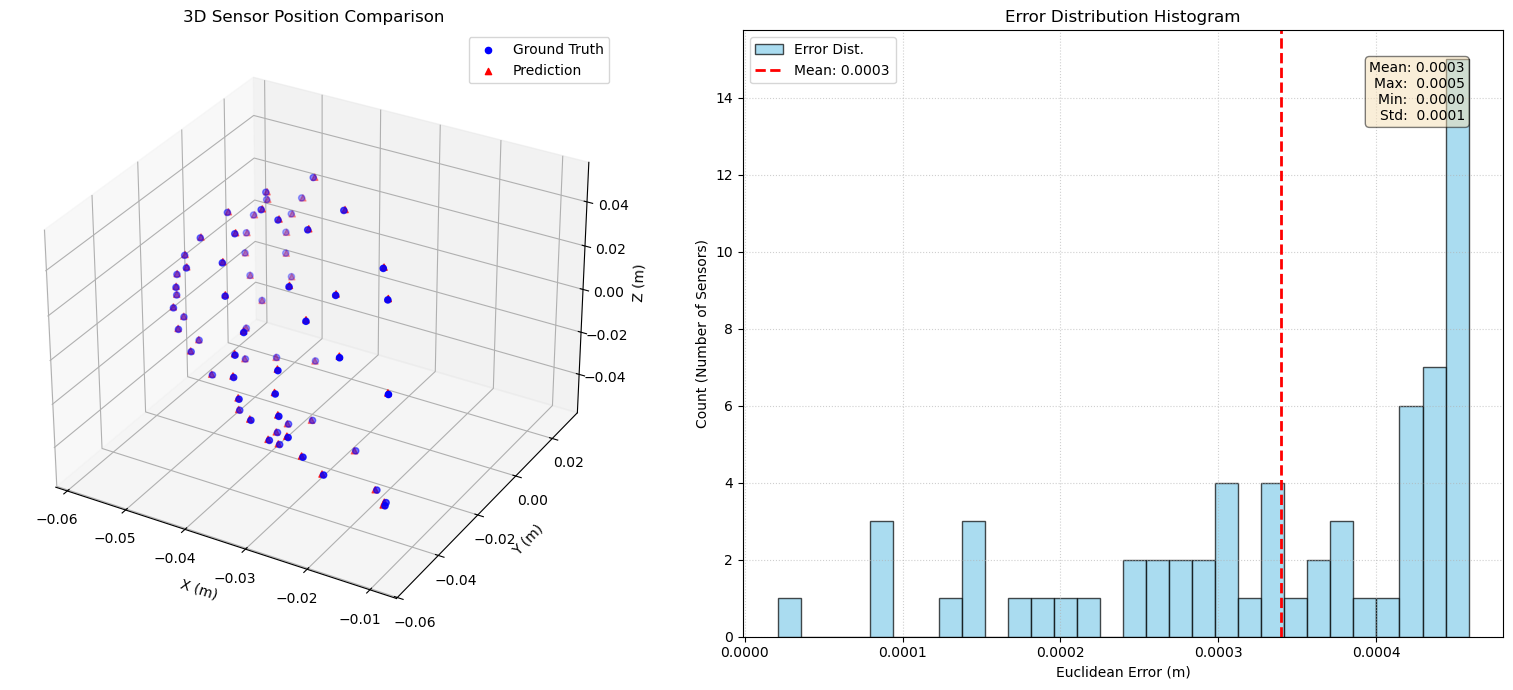

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 读取数据
sensor_loc_new_pos = np.loadtxt('sensor_location_120_real.txt')
sensor_loc_new_pos_predict = np.loadtxt('predicted_array_location_finetuned_masked.txt')


# ----------------------
# 1. 计算误差 (Calculate Error)
# ----------------------
errors = np.linalg.norm(sensor_loc_new_pos - sensor_loc_new_pos_predict, axis=1)

mean_error = np.mean(errors)
max_error = np.max(errors)
min_error = np.min(errors)
std_error = np.std(errors) # 新增标准差

print(f"=== 误差统计 ===")
print(f"平均误差 (Mean): {mean_error:.6f}")
print(f"最大误差 (Max) : {max_error:.6f}")
print(f"最小误差 (Min) : {min_error:.6f}")
print(f"标准差   (Std) : {std_error:.6f}")

# ----------------------
# 2. 可视化 (Visualization)
# ----------------------
# 设置画布大小，改为宽图以容纳两个子图
fig = plt.figure(figsize=(16, 7))

# === 子图 1: 3D 空间对比图 ===
ax1 = fig.add_subplot(121, projection='3d')

# 绘制真实值
ax1.scatter(sensor_loc_new_pos[:, 0], 
            sensor_loc_new_pos[:, 1], 
            sensor_loc_new_pos[:, 2], 
            c='blue', marker='o', s=20, label='Ground Truth')

# 绘制预测值
ax1.scatter(sensor_loc_new_pos_predict[:, 0], 
            sensor_loc_new_pos_predict[:, 1], 
            sensor_loc_new_pos_predict[:, 2], 
            c='red', marker='^', s=20, label='Prediction')

# 绘制连接线
for i in range(len(sensor_loc_new_pos)):
    ax1.plot([sensor_loc_new_pos[i, 0], sensor_loc_new_pos_predict[i, 0]],
             [sensor_loc_new_pos[i, 1], sensor_loc_new_pos_predict[i, 1]],
             [sensor_loc_new_pos[i, 2], sensor_loc_new_pos_predict[i, 2]],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('3D Sensor Position Comparison')
ax1.legend()

# === 子图 2: 误差分布直方图 (新增部分) ===
ax2 = fig.add_subplot(122)

# 绘制直方图
n, bins, patches = ax2.hist(errors, bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Error Dist.')

# 绘制平均误差竖线
ax2.axvline(mean_error, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_error:.4f}')

# 添加统计信息文本框
textstr = '\n'.join((
    f'Mean: {mean_error:.4f}',
    f'Max:  {max_error:.4f}',
    f'Min:  {min_error:.4f}',
    f'Std:  {std_error:.4f}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

ax2.set_xlabel('Euclidean Error (m)')
ax2.set_ylabel('Count (Number of Sensors)')
ax2.set_title('Error Distribution Histogram')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

=== 误差统计 ===
平均误差 (Mean): 0.000523
最大误差 (Max) : 0.000828
最小误差 (Min) : 0.000115
标准差   (Std) : 0.000189


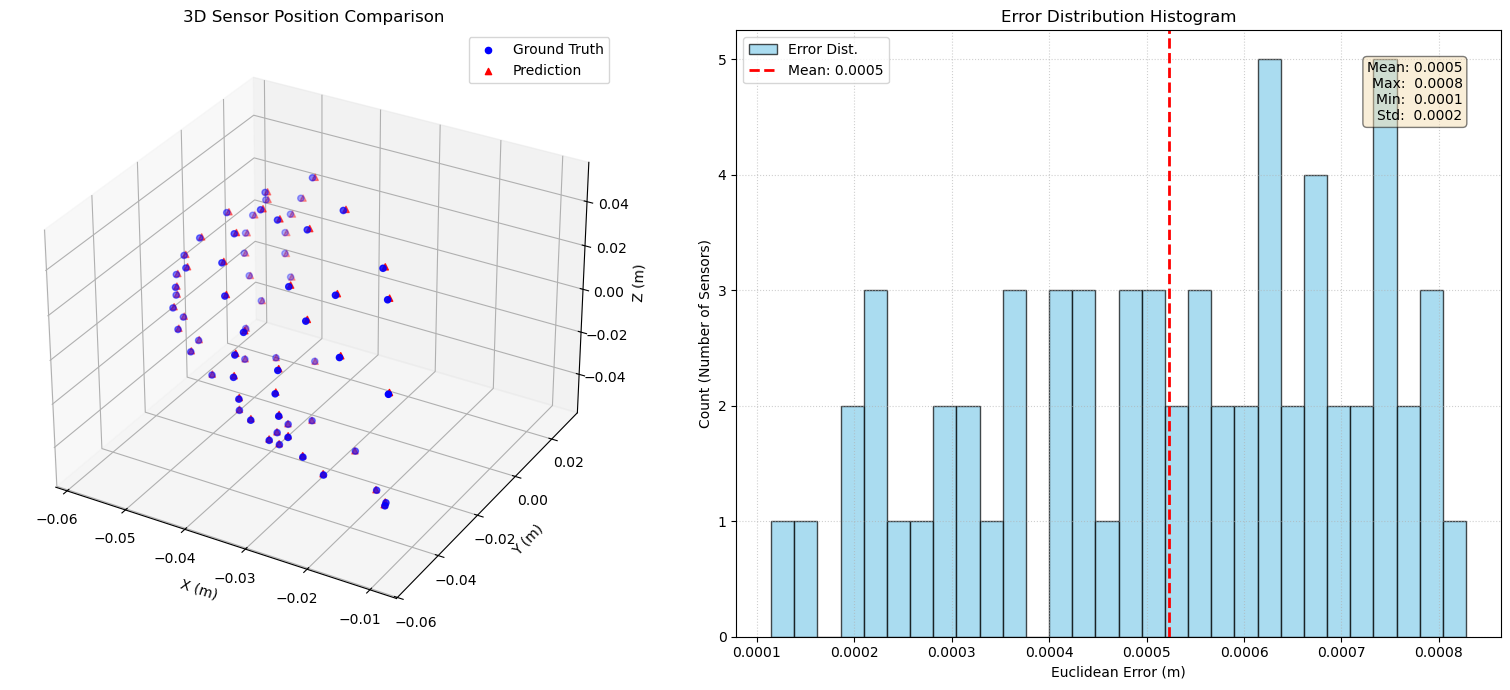

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 读取数据
sensor_loc_new_pos = np.loadtxt('sensor_location_120_real.txt')
sensor_loc_new_pos_predict = np.loadtxt('predicted_array_location_corrected.txt')


# ----------------------
# 1. 计算误差 (Calculate Error)
# ----------------------
errors = np.linalg.norm(sensor_loc_new_pos - sensor_loc_new_pos_predict, axis=1)

mean_error = np.mean(errors)
max_error = np.max(errors)
min_error = np.min(errors)
std_error = np.std(errors) # 新增标准差

print(f"=== 误差统计 ===")
print(f"平均误差 (Mean): {mean_error:.6f}")
print(f"最大误差 (Max) : {max_error:.6f}")
print(f"最小误差 (Min) : {min_error:.6f}")
print(f"标准差   (Std) : {std_error:.6f}")

# ----------------------
# 2. 可视化 (Visualization)
# ----------------------
# 设置画布大小，改为宽图以容纳两个子图
fig = plt.figure(figsize=(16, 7))

# === 子图 1: 3D 空间对比图 ===
ax1 = fig.add_subplot(121, projection='3d')

# 绘制真实值
ax1.scatter(sensor_loc_new_pos[:, 0], 
            sensor_loc_new_pos[:, 1], 
            sensor_loc_new_pos[:, 2], 
            c='blue', marker='o', s=20, label='Ground Truth')

# 绘制预测值
ax1.scatter(sensor_loc_new_pos_predict[:, 0], 
            sensor_loc_new_pos_predict[:, 1], 
            sensor_loc_new_pos_predict[:, 2], 
            c='red', marker='^', s=20, label='Prediction')

# 绘制连接线
for i in range(len(sensor_loc_new_pos)):
    ax1.plot([sensor_loc_new_pos[i, 0], sensor_loc_new_pos_predict[i, 0]],
             [sensor_loc_new_pos[i, 1], sensor_loc_new_pos_predict[i, 1]],
             [sensor_loc_new_pos[i, 2], sensor_loc_new_pos_predict[i, 2]],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('3D Sensor Position Comparison')
ax1.legend()

# === 子图 2: 误差分布直方图 (新增部分) ===
ax2 = fig.add_subplot(122)

# 绘制直方图
n, bins, patches = ax2.hist(errors, bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Error Dist.')

# 绘制平均误差竖线
ax2.axvline(mean_error, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_error:.4f}')

# 添加统计信息文本框
textstr = '\n'.join((
    f'Mean: {mean_error:.4f}',
    f'Max:  {max_error:.4f}',
    f'Min:  {min_error:.4f}',
    f'Std:  {std_error:.4f}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

ax2.set_xlabel('Euclidean Error (m)')
ax2.set_ylabel('Count (Number of Sensors)')
ax2.set_title('Error Distribution Histogram')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# # 定义保存路径
# save_path = 'sensor_location_120_real.txt'

# # 保存为 txt 文件
# # fmt='%.6f' 表示保留6位小数的浮点数
# # delimiter=' ' 表示用空格分隔（默认也是空格）
# # header='x y z' 可选，在文件开头添加列名
# np.savetxt(save_path, sensor_loc_new_pos_part, fmt='%.6f', delimiter=' ', header='x y z')

# print(f"已将数据保存至: {save_path}")

已将数据保存至: sensor_location_120_real.txt
